In [1]:
!pip install -q torch torchvision datasets huggingface_hub wandb pillow matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from datasets import load_dataset
import wandb
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import os

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# Hyperparameters
CONFIG = {
    'batch_size': 32,
    'num_epochs': 10,
    'learning_rate': 1e-3,
    'num_classes': 10,
    'image_size': 224,
    'num_workers': 4,
    'seed': 42
}

# Set random seed for reproducibility
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

In [4]:
# Initialize wandb
wandb.login()

# Start a new run
run = wandb.init(
    project="stl10-resnet18",
    config=CONFIG,
    name="resnet18-stl10-complete-pipeline"
)

config = wandb.config
print("WandB initialized successfully!")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: m25csa007 (m25csa007-indian-institute-of-technology-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB initialized successfully!


In [5]:
# Load dataset from Hugging Face
print("Loading STL-10 Subset dataset...")
dataset = load_dataset("Chiranjeev007/STL-10_Subset")

print("\nDataset structure:")
print(dataset)

# Get train and test splits
train_dataset = dataset['train']
test_dataset = dataset['test'] if 'test' in dataset else dataset['validation']

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Check the class names
class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
print(f"\nClasses: {class_names}")

Loading STL-10 Subset dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/723 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/88.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/8.82M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 500
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})

Train samples: 5000
Test samples: 1000

Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [6]:
class STL10CustomDataset(Dataset):
    """Custom Dataset for STL-10 from Hugging Face"""

    def __init__(self, hf_dataset, transform=None):
        """
        Args:
            hf_dataset: Hugging Face dataset split
            transform: Optional transform to be applied on images
        """
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        # Get image and label
        image = item['image']
        label = item['label']

        # Convert to PIL Image if not already
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

print("Custom Dataset class defined!")

Custom Dataset class defined!


In [7]:
# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create custom datasets
train_custom_dataset = STL10CustomDataset(train_dataset, transform=train_transform)
test_custom_dataset = STL10CustomDataset(test_dataset, transform=test_transform)

# Create dataloaders
train_loader = DataLoader(
    train_custom_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_custom_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 157
Test batches: 32


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


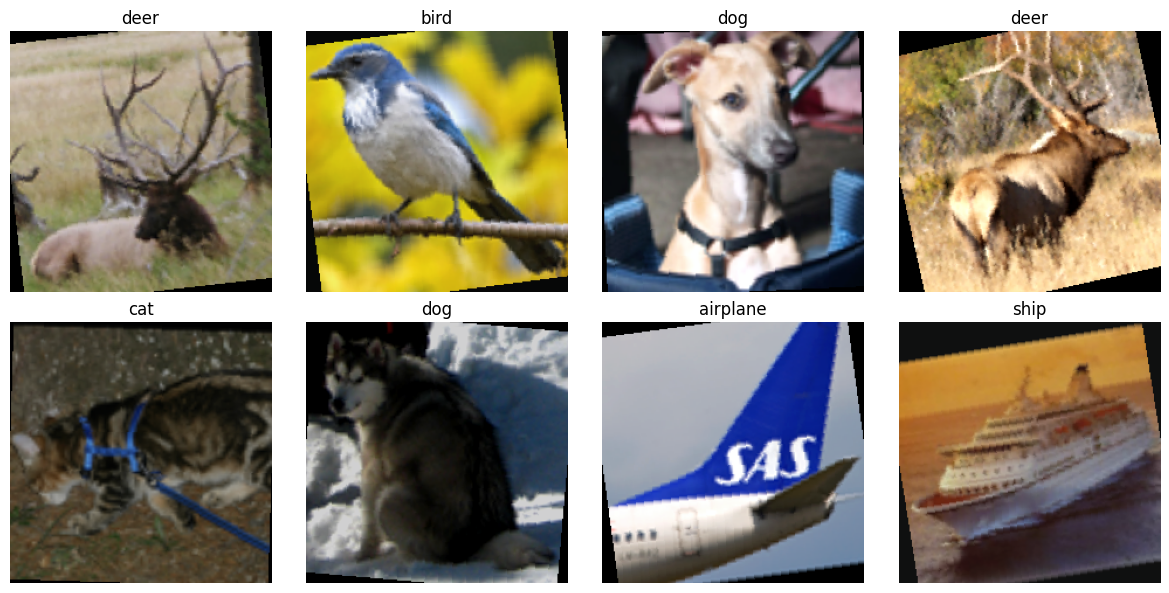

In [8]:
# Visualize some samples
def imshow(img, title=None):
    """Display image"""
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Get a batch of training data
images, labels = next(iter(train_loader))

# Plot sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for idx, ax in enumerate(axes.flat):
    if idx < len(images):
        plt.sca(ax)
        imshow(images[idx], title=class_names[labels[idx]])
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to wandb
wandb.log({"sample_images": wandb.Image('sample_images.png')})

In [9]:
# Load pretrained ResNet-18 with ImageNet weights
model = models.resnet18(pretrained=True)

# Modify the final layer for our number of classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, CONFIG['num_classes'])

# Move model to device
model = model.to(DEVICE)

print("ResNet-18 model initialized with ImageNet pretrained weights!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Device: {DEVICE}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


ResNet-18 model initialized with ImageNet pretrained weights!
Total parameters: 11,181,642
Trainable parameters: 11,181,642
Device: cuda


In [10]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2,
)

print("Loss function and optimizer configured!")

Loss function and optimizer configured!


In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Validation')
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * correct / total:.2f}%'
            })

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

print("Training and validation functions defined!")

Training and validation functions defined!


In [12]:
# Track metrics
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_path = 'best_resnet18_stl10.pth'

print("Starting training...\n")

for epoch in range(CONFIG['num_epochs']):
    print(f"\nEpoch [{epoch+1}/{CONFIG['num_epochs']}]")
    print("-" * 60)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validate
    val_loss, val_acc = validate_epoch(model, test_loader, criterion, DEVICE)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Log to WandB
    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'learning_rate': optimizer.param_groups[0]['lr']
    })

    # Print epoch summary
    print(f"\nEpoch Summary:")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f"✓ Best model saved with validation accuracy: {val_acc:.2f}%")

print("\n" + "="*60)
print("Training completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print("="*60)

Starting training...


Epoch [1/10]
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:02<00:00, 12.44it/s, loss=1.4202, acc=72.80%]



Epoch Summary:
Train Loss: 0.9592 | Train Acc: 66.68%
Val Loss:   0.8060 | Val Acc:   72.80%
✓ Best model saved with validation accuracy: 72.80%

Epoch [2/10]
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:02<00:00, 13.30it/s, loss=0.4578, acc=77.80%]



Epoch Summary:
Train Loss: 0.6696 | Train Acc: 77.18%
Val Loss:   0.6327 | Val Acc:   77.80%
✓ Best model saved with validation accuracy: 77.80%

Epoch [3/10]
------------------------------------------------------------


...


Epoch Summary:
Train Loss: 0.1381 | Train Acc: 95.32%
Val Loss:   0.4794 | Val Acc:   86.40%

Epoch [9/10]
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:02<00:00, 11.38it/s, loss=0.0604, acc=85.60%]



Epoch Summary:
Train Loss: 0.1398 | Train Acc: 95.22%
Val Loss:   0.4833 | Val Acc:   85.60%

Epoch [10/10]
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:03<00:00,  9.98it/s, loss=0.1294, acc=89.80%]


Epoch Summary:
Train Loss: 0.0804 | Train Acc: 97.46%
Val Loss:   0.3215 | Val Acc:   89.80%

Training completed!
Best validation accuracy: 90.40%


In [15]:
!huggingface-cli login

/bin/bash: line 1: huggingface-cli: command not found


In [18]:
from huggingface_hub import login, whoami

# Login to HuggingFace Hub
print("=" * 60)
print("HUGGING FACE AUTHENTICATION")
print("=" * 60)

try:
    # Try to get current user info (will fail if not logged in)
    user_info = whoami()
    print(f"✓ Already logged in as: {user_info['name']}")
    HF_USERNAME = user_info['name']
except:
    print("\n⚠️ Not logged in to Hugging Face.")
    print("\nPlease login to Hugging Face:")
    print("Option 1: Use the login() function below")
    print("Option 2: Run in terminal: huggingface-cli login")
    print("\nTo get your token:")
    print("1. Go to https://huggingface.co/settings/tokens")
    print("2. Create a new token with 'write' access")
    print("3. Copy the token and paste it when prompted")
    print("\n" + "=" * 60)

    # Interactive login
    login()

    # Verify login
    user_info = whoami()
    print(f"\n✓ Successfully logged in as: {user_info['name']}")
    HF_USERNAME = user_info['name']

print(f"\n✅ Ready to push models as: {HF_USERNAME}")
print("=" * 60)

HUGGING FACE AUTHENTICATION
✓ Already logged in as: DuckyDuck123

✅ Ready to push models as: DuckyDuck123


In [19]:
from huggingface_hub import HfApi, create_repo, upload_file
import os

# Configuration for HuggingFace Hub
HF_USERNAME = "DuckyDuck123"  # ⚠️ UPDATE THIS with your HuggingFace username
HF_MODEL_NAME = "resnet18-stl10"  # Model repository name
HF_REPO_ID = f"{HF_USERNAME}/{HF_MODEL_NAME}"

print(f"Pushing model to Hugging Face Hub: {HF_REPO_ID}")
print("=" * 60)

try:
    # Login to HuggingFace (make sure you've run 'huggingface-cli login' first)
    api = HfApi()

    # Create repository (will skip if already exists)
    try:
        create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)
        print(f"✓ Repository created/verified: {HF_REPO_ID}")
    except Exception as e:
        print(f"Note: {e}")

    # Upload the model file
    print("\nUploading model file...")
    upload_file(
        path_or_fileobj=best_model_path,
        path_in_repo="pytorch_model.pth",
        repo_id=HF_REPO_ID,
        repo_type="model"
    )
    print(f"✓ Model uploaded successfully!")

    # Create and upload a README
    readme_content = f"""---
tags:
- image-classification
- pytorch
- resnet
- stl10
license: apache-2.0
---

# ResNet-18 trained on STL-10 Subset

This model is a ResNet-18 architecture trained on the STL-10 Subset dataset.

## Model Details
- **Architecture**: ResNet-18
- **Dataset**: STL-10 Subset (10 classes)
- **Classes**: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck
- **Best Validation Accuracy**: {best_val_acc:.2f}%
- **Framework**: PyTorch

## Usage

```python
import torch
from torchvision import models
from huggingface_hub import hf_hub_download

# Load model
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 10)

# Download weights
model_path = hf_hub_download(repo_id="{HF_REPO_ID}", filename="pytorch_model.pth")
checkpoint = torch.load(model_path, map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
```

## Training Details
- Optimizer: Adam
- Learning Rate: {CONFIG['learning_rate']}
- Batch Size: {CONFIG['batch_size']}
- Epochs: {CONFIG['num_epochs']}
"""

    with open("README.md", "w") as f:
        f.write(readme_content)

    upload_file(
        path_or_fileobj="README.md",
        path_in_repo="README.md",
        repo_id=HF_REPO_ID,
        repo_type="model"
    )
    print(f"✓ README uploaded successfully!")

    print("\n" + "=" * 60)
    print(f"✅ Model successfully pushed to Hugging Face!")
    print(f"🔗 View at: https://huggingface.co/{HF_REPO_ID}")
    print("=" * 60)

    # Store the repo ID for later use
    MODEL_REPO = HF_REPO_ID

except Exception as e:
    print(f"\n❌ Error pushing to Hugging Face: {e}")
    print("\nMake sure you have:")
    print("1. Updated HF_USERNAME with your HuggingFace username")
    print("2. Logged in with: huggingface-cli login")
    print("3. Have write access to the repository")
    raise

Pushing model to Hugging Face Hub: DuckyDuck123/resnet18-stl10
✓ Repository created/verified: DuckyDuck123/resnet18-stl10

Uploading model file...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  best_resnet18_stl10.pth     :   0%|          |  571kB /  134MB            

✓ Model uploaded successfully!
✓ README uploaded successfully!

✅ Model successfully pushed to Hugging Face!
🔗 View at: https://huggingface.co/DuckyDuck123/resnet18-stl10


In [20]:
from huggingface_hub import hf_hub_download

print(f"Loading model from Hugging Face Hub: {MODEL_REPO}")
print("=" * 60)

# Create a fresh model instance
eval_model = models.resnet18(pretrained=False)
eval_model.fc = nn.Linear(eval_model.fc.in_features, CONFIG['num_classes'])

try:
    # Download the model from HuggingFace
    downloaded_model_path = hf_hub_download(
        repo_id=MODEL_REPO,
        filename="pytorch_model.pth",
        repo_type="model"
    )

    print(f"✓ Model downloaded from HuggingFace")
    print(f"  Downloaded to: {downloaded_model_path}")

    # Load the state dict
    checkpoint = torch.load(downloaded_model_path, map_location=DEVICE)

    # Handle different checkpoint formats
    if 'model_state_dict' in checkpoint:
        eval_model.load_state_dict(checkpoint['model_state_dict'])
        print(f"  Validation accuracy: {checkpoint.get('val_acc', 'N/A')}")
    else:
        eval_model.load_state_dict(checkpoint)

    # Move to device and set to evaluation mode
    eval_model = eval_model.to(DEVICE)
    eval_model.eval()

    print(f"✓ Model loaded successfully from HuggingFace!")
    print(f"  Total parameters: {sum(p.numel() for p in eval_model.parameters()):,}")
    print("=" * 60)

except Exception as e:
    print(f"\n❌ Error loading model from HuggingFace: {e}")
    print("\nUsing the locally trained model instead...")
    eval_model = model  # Use the model we just trained
    eval_model.eval()

print(f"\n✅ Model ready for evaluation!")

Loading model from Hugging Face Hub: DuckyDuck123/resnet18-stl10


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


pytorch_model.pth:   0%|          | 0.00/134M [00:00<?, ?B/s]

✓ Model downloaded from HuggingFace
  Downloaded to: /root/.cache/huggingface/hub/models--DuckyDuck123--resnet18-stl10/snapshots/308b716f9d9902659fa0f71ba6e9edc72358a15c/pytorch_model.pth
  Validation accuracy: 90.4
✓ Model loaded successfully from HuggingFace!
  Total parameters: 11,181,642

✅ Model ready for evaluation!


In [21]:

# Evaluate the model loaded from HuggingFace on test set
print("Evaluating model on test set...")
eval_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = eval_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate per-class accuracy
class_correct = [0] * CONFIG['num_classes']
class_total = [0] * CONFIG['num_classes']

for label, pred in zip(all_labels, all_preds):
    if label == pred:
        class_correct[label] += 1
    class_total[label] += 1

# Calculate per-class accuracies
class_accuracies = []
print("\nPer-class Accuracy:")
print("-" * 40)
for i, class_name in enumerate(class_names):
    acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    class_accuracies.append(acc)
    print(f"{class_name:12s}: {acc:6.2f}%")
print("-" * 40)
overall_acc = 100 * sum(class_correct) / sum(class_total)
print(f"{'Overall':12s}: {overall_acc:6.2f}%")

# Log overall accuracy to WandB
wandb.log({"test_accuracy": overall_acc})

Evaluating model on test set...


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Evaluating: 100%|██████████| 32/32 [00:03<00:00,  9.89it/s]


Per-class Accuracy:
----------------------------------------
airplane    :  99.00%
bird        :  94.00%
car         : 100.00%
cat         :  86.00%
deer        :  88.00%
dog         :  80.00%
horse       :  88.00%
monkey      :  84.00%
ship        :  93.00%
truck       :  92.00%
----------------------------------------
Overall     :  90.40%


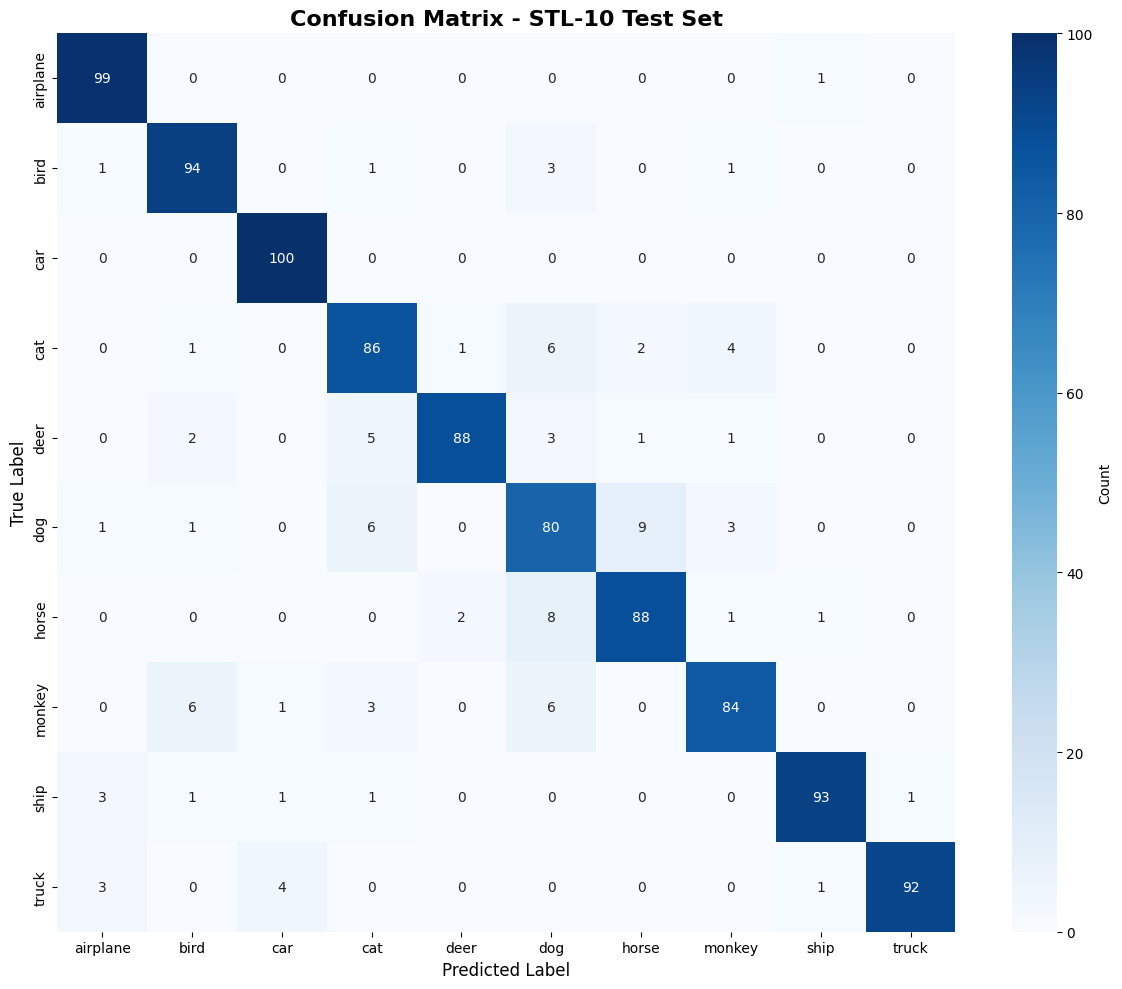

Confusion matrix saved and logged to WandB!


In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - STL-10 Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Log confusion matrix to WandB
wandb.log({
    "confusion_matrix": wandb.Image('confusion_matrix_test.png')
})

# Also log as wandb confusion matrix table
wandb.log({
    "conf_mat": wandb.plot.confusion_matrix(
        probs=None,
        y_true=all_labels,
        preds=all_preds,
        class_names=class_names
    )
})

print("Confusion matrix saved and logged to WandB!")

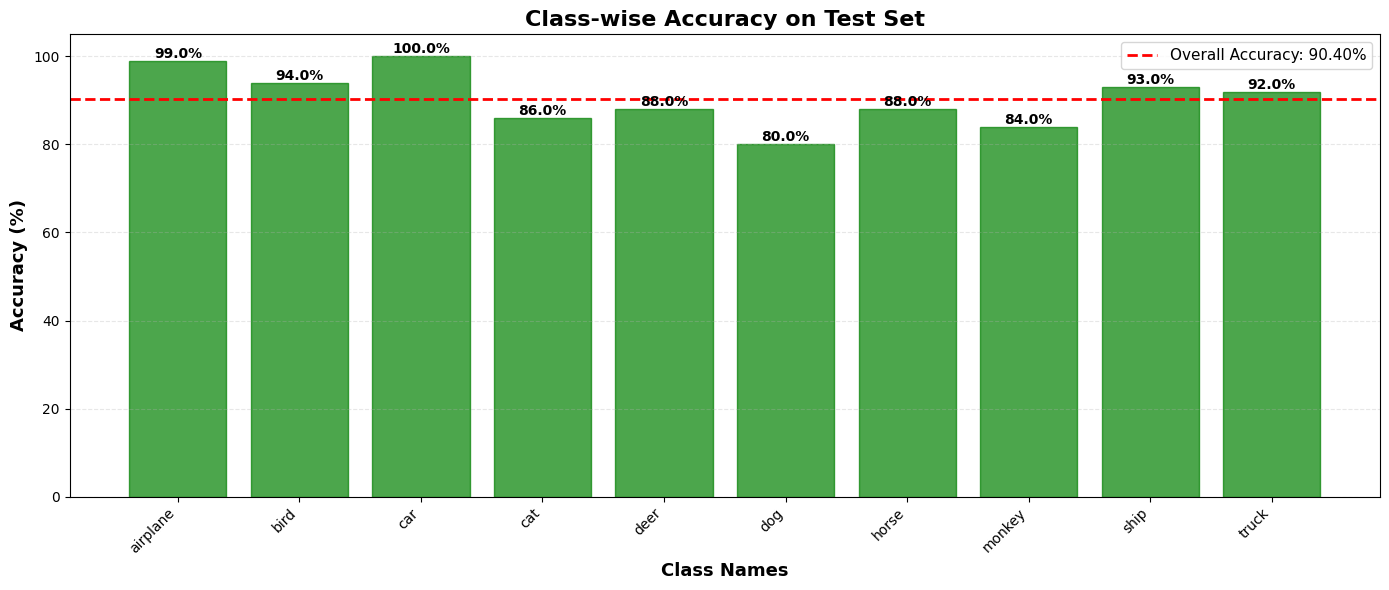

Class-wise accuracy bar plot saved and logged to WandB!


In [23]:
# Create bar plot for class-wise accuracy
plt.figure(figsize=(14, 6))
bars = plt.bar(class_names, class_accuracies, color='steelblue', alpha=0.8, edgecolor='black')

# Color bars based on accuracy (green for high, yellow for medium, red for low)
colors = []
for acc in class_accuracies:
    if acc >= 80:
        colors.append('green')
    elif acc >= 60:
        colors.append('orange')
    else:
        colors.append('red')

for bar, color in zip(bars, colors):
    bar.set_color(color)
    bar.set_alpha(0.7)

# Add value labels on top of bars
for i, (bar, acc) in enumerate(zip(bars, class_accuracies)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add overall accuracy line
plt.axhline(y=overall_acc, color='red', linestyle='--', linewidth=2,
            label=f'Overall Accuracy: {overall_acc:.2f}%')

plt.xlabel('Class Names', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
plt.title('Class-wise Accuracy on Test Set', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('classwise_accuracy_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Log to WandB
wandb.log({"classwise_accuracy_barplot": wandb.Image('classwise_accuracy_barplot.png')})

# Also log as a bar chart
data = [[label, acc] for label, acc in zip(class_names, class_accuracies)]
table = wandb.Table(data=data, columns=["class", "accuracy"])
wandb.log({
    "class_accuracy_chart": wandb.plot.bar(table, "class", "accuracy",
                                           title="Class-wise Accuracy")
})

print("Class-wise accuracy bar plot saved and logged to WandB!")

In [24]:
# Save evaluation results
import json

results = {
    'overall_accuracy': float(overall_acc),
    'class_accuracies': {class_name: float(acc) for class_name, acc in zip(class_names, class_accuracies)},
    'confusion_matrix': cm.tolist(),
    'class_names': class_names,
    'total_samples': len(all_labels)
}

# Save to JSON file
with open('evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("Evaluation results saved to 'evaluation_results.json'")

# Upload results to WandB
wandb.save('evaluation_results.json')
wandb.save('confusion_matrix_test.png')
wandb.save('classwise_accuracy_barplot.png')

# Log final summary to WandB
wandb.summary['test_accuracy'] = overall_acc
wandb.summary['best_class'] = class_names[np.argmax(class_accuracies)]
wandb.summary['worst_class'] = class_names[np.argmin(class_accuracies)]
wandb.summary['best_class_accuracy'] = max(class_accuracies)
wandb.summary['worst_class_accuracy'] = min(class_accuracies)

print("\nEvaluation Summary:")
print(f"  Overall Accuracy: {overall_acc:.2f}%")
print(f"  Best Class: {class_names[np.argmax(class_accuracies)]} ({max(class_accuracies):.2f}%)")
print(f"  Worst Class: {class_names[np.argmin(class_accuracies)]} ({min(class_accuracies):.2f}%)")
print("\nAll results uploaded to WandB!")

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Evaluation results saved to 'evaluation_results.json'

Evaluation Summary:
  Overall Accuracy: 90.40%
  Best Class: car (100.00%)
  Worst Class: dog (80.00%)

All results uploaded to WandB!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Collected 10 correct and 10 incorrect predictions


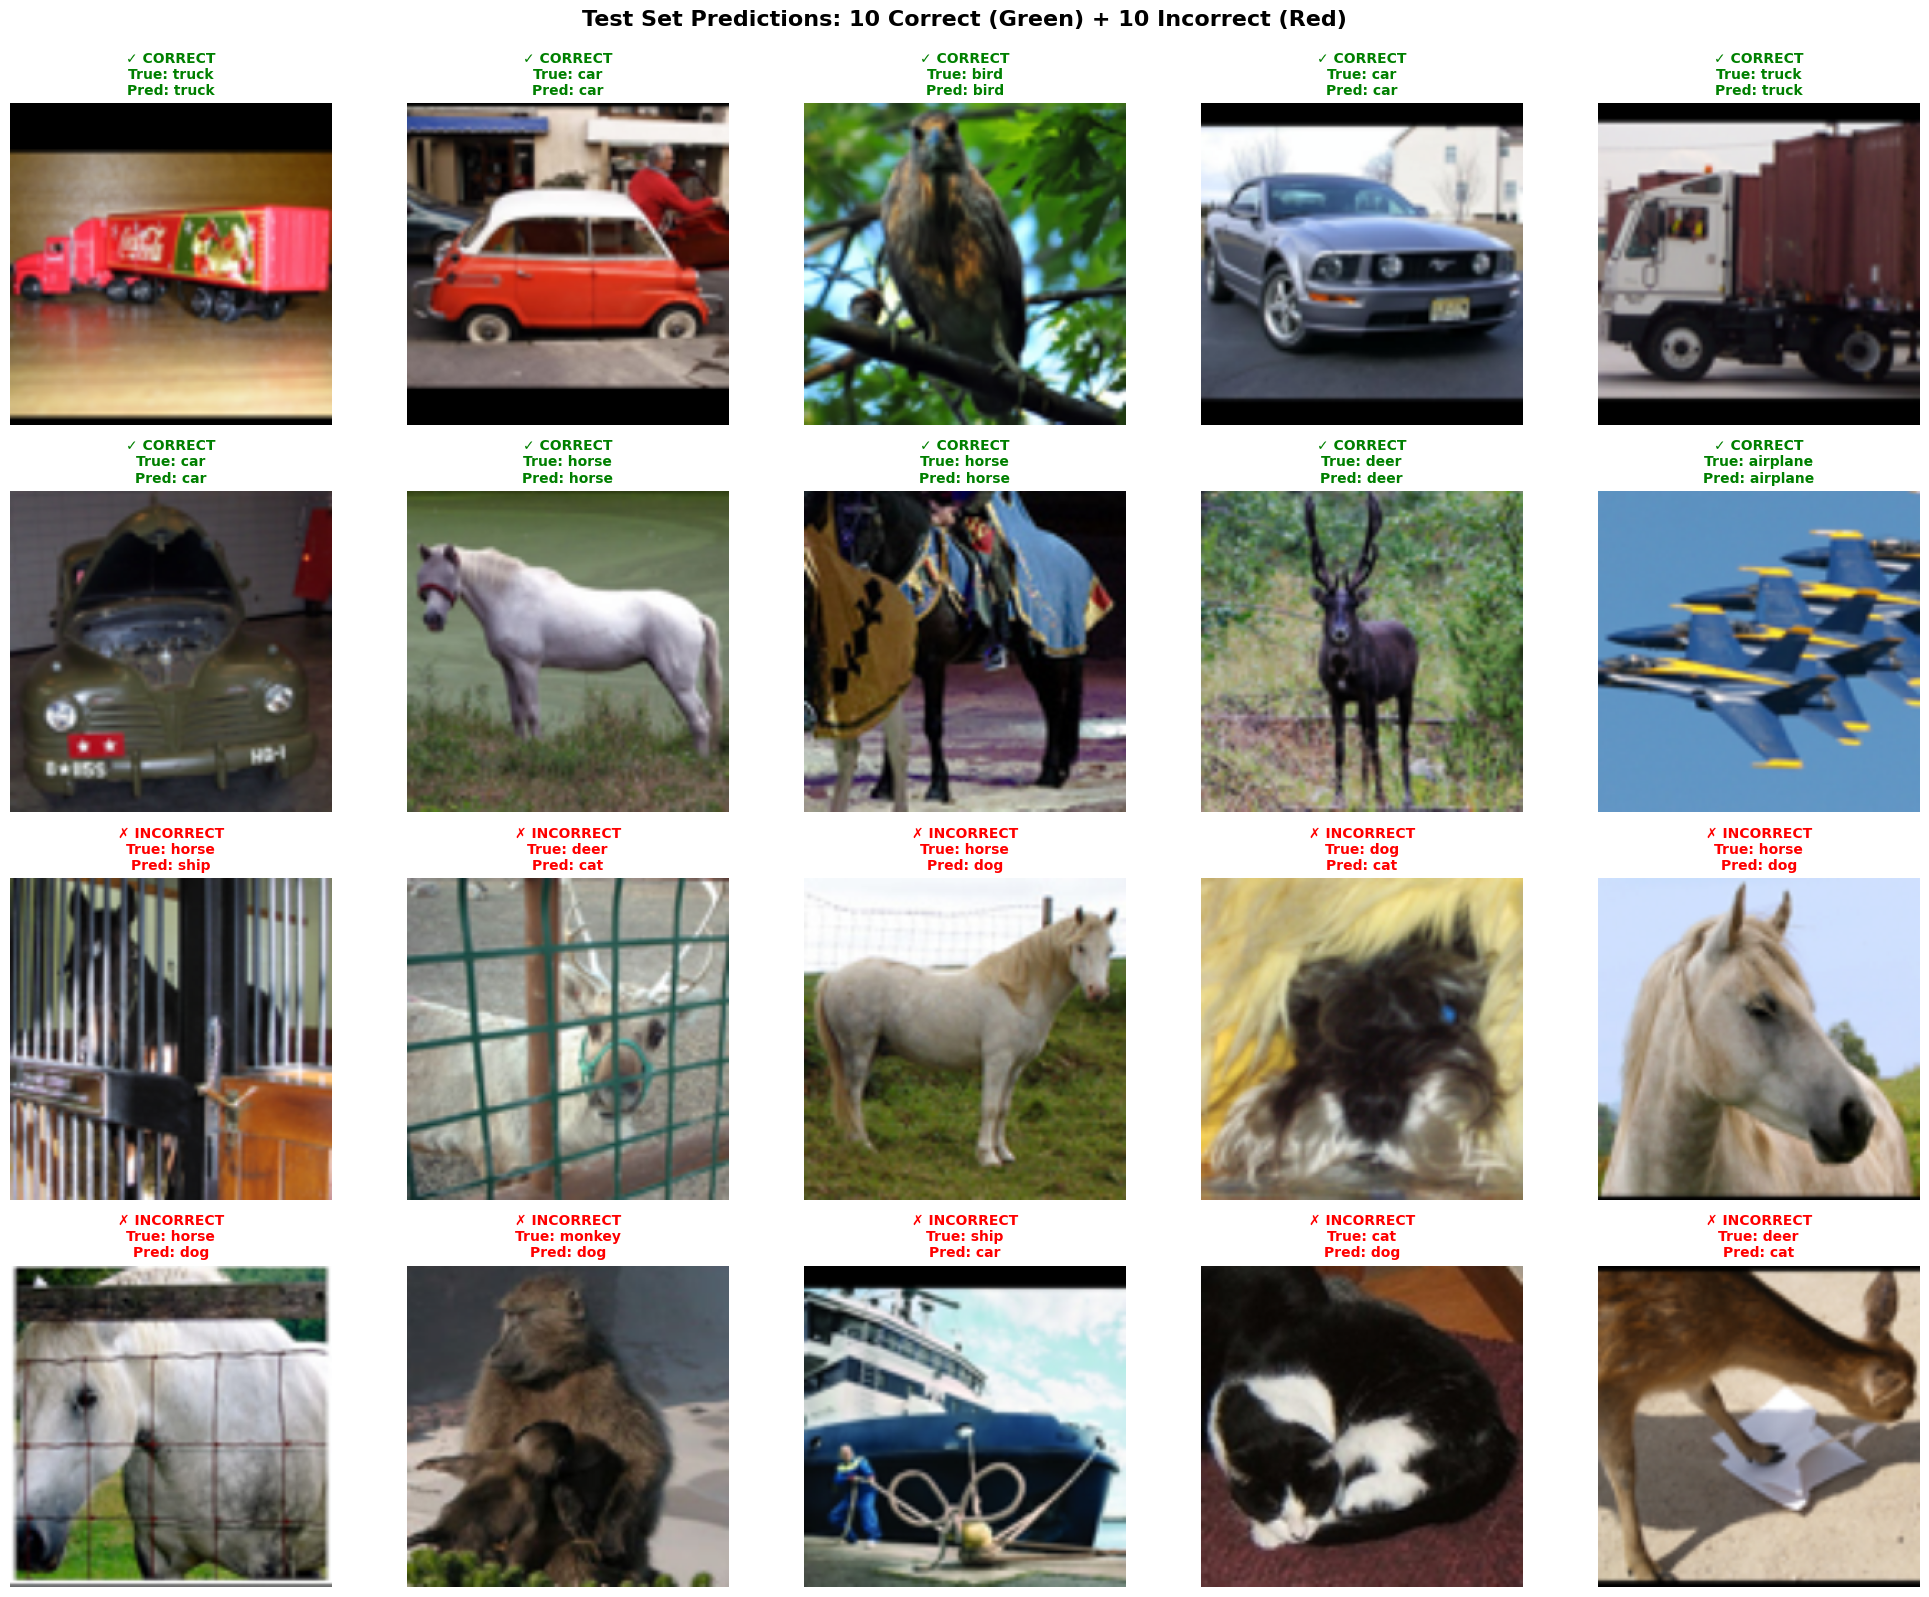


Sample predictions visualization saved!
✓ Sample predictions logged to WandB as image and interactive table!
  - 10 Correct predictions
  - 10 Incorrect predictions


In [25]:
# Collect correct and incorrect predictions for visualization
print("Collecting sample predictions...")
eval_model.eval()

correct_samples = []
incorrect_samples = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = eval_model(images)
        _, preds = torch.max(outputs, 1)

        # Separate correct and incorrect predictions
        for i in range(len(images)):
            sample = {
                'image': images[i].cpu(),
                'true_label': labels[i].item(),
                'pred_label': preds[i].item()
            }

            if labels[i] == preds[i] and len(correct_samples) < 10:
                correct_samples.append(sample)
            elif labels[i] != preds[i] and len(incorrect_samples) < 10:
                incorrect_samples.append(sample)

        # Stop when we have enough samples
        if len(correct_samples) >= 10 and len(incorrect_samples) >= 10:
            break

print(f"Collected {len(correct_samples)} correct and {len(incorrect_samples)} incorrect predictions")

# Visualize the samples
def denormalize_image(img_tensor):
    """Denormalize image for display"""
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Create visualization with 4 rows x 5 columns = 20 images
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

# Plot correct predictions (first 10)
for idx, sample in enumerate(correct_samples):
    ax = axes[idx]
    img = denormalize_image(sample['image'])
    ax.imshow(img)

    true_label = class_names[sample['true_label']]
    pred_label = class_names[sample['pred_label']]

    ax.set_title(f'✓ CORRECT\nTrue: {true_label}\nPred: {pred_label}',
                color='green', fontsize=10, fontweight='bold')
    ax.axis('off')

# Plot incorrect predictions (next 10)
for idx, sample in enumerate(incorrect_samples):
    ax = axes[idx + 10]
    img = denormalize_image(sample['image'])
    ax.imshow(img)

    true_label = class_names[sample['true_label']]
    pred_label = class_names[sample['pred_label']]

    ax.set_title(f'✗ INCORRECT\nTrue: {true_label}\nPred: {pred_label}',
                color='red', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Test Set Predictions: 10 Correct (Green) + 10 Incorrect (Red)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('test_predictions_20_samples.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nSample predictions visualization saved!")

# Log to WandB
wandb.log({"test_predictions_20_samples": wandb.Image('test_predictions_20_samples.png')})

# Also log as WandB Table for interactive viewing
columns = ["image", "true_label", "predicted_label", "correct"]
data = []

# Add correct samples
for sample in correct_samples:
    img = denormalize_image(sample['image'])
    data.append([
        wandb.Image(img),
        class_names[sample['true_label']],
        class_names[sample['pred_label']],
        "✓ Correct"
    ])

# Add incorrect samples
for sample in incorrect_samples:
    img = denormalize_image(sample['image'])
    data.append([
        wandb.Image(img),
        class_names[sample['true_label']],
        class_names[sample['pred_label']],
        "✗ Incorrect"
    ])

# Create and log the table
predictions_table = wandb.Table(data=data, columns=columns)
wandb.log({"predictions_table": predictions_table})

print("✓ Sample predictions logged to WandB as image and interactive table!")
print(f"  - 10 Correct predictions")
print(f"  - 10 Incorrect predictions")

In [26]:
# Finish the WandB run
wandb.finish()
print("WandB run finished successfully!")
print(f"\n✅ Evaluation Complete!")
print(f"View your results at: https://wandb.ai/")

epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,████▃▃▃▃▁▁
test_accuracy,▁
train_acc,▁▃▄▅▅▇██▇█
train_loss,█▆▅▄▄▂▁▁▁▁
val_acc,▁▃▂▃▂██▆▆█
val_loss,▇▅█▆█▁▁▃▃▁
best_class,car
best_class_accuracy,100
epoch,10
learning_rate,0.00025


WandB run finished successfully!

✅ Evaluation Complete!
View your results at: https://wandb.ai/
